In [1]:
import torch
import matplotlib.pyplot as plt
import io
import math
import random
from PIL import Image


In [2]:
import glob
import pandas as pd

files = sorted(glob.glob("/home/shared/data/imagenet/validation-*.parquet"))

df = pd.read_parquet(files)

In [3]:
def show_imgnet(idx, df=df, title=None):
    img_bytes = df.loc[idx, 'image']['bytes']
    img = Image.open(io.BytesIO(img_bytes))

    plt.imshow(img)
    plt.axis("off")
    if title != None:
        plt.title(title)

def show_img(img, title=None):
    img = img.squeeze()

    plt.imshow(img, cmap='gray')
    if title != None:
        plt.title(title)
    plt.axis('off')


In [4]:
def get_imgnet_img(idx):
    img_bytes = df.loc[idx, 'image']['bytes']
    img = Image.open(io.BytesIO(img_bytes))
    return img


In [6]:
from matplotlib.patches import Rectangle


In [5]:
def get_knn(msgs, query_idx, k=5, batch_size=32, in_batch=False, dataset='imagenet', plot=True):
    
    if in_batch:
        start = batch_size * (query_idx // batch_size)
        end = start + batch_size
        query_idx = query_idx % batch_size
    else:
        start = 0
        end = len(msgs["words"])
        
    words = msgs["words"][start:end]
    query = words[query_idx]

    msg_dist = (words != query).sum(dim=-1)

    # exclude self
    msg_dist[query_idx] = 100

    knn = torch.topk(msg_dist, k, largest=False)
    
    nearest_idxs = knn.indices
    
    if plot:
        rows = math.ceil(k / 5)

        fig, axes = plt.subplots(rows, 5, figsize=(15, rows * 3))

        axes = axes.flatten()
        for ax, idx, dist in zip(axes, nearest_idxs, knn.values):
            plt.sca(ax)
            if dataset == 'imagenet': # Msg: {words[idx].tolist()}
                show_imgnet(msgs['indices'][start:end][idx].item(), title=f"Dist: {dist.item()} - L: {msgs['labels'][start:end][idx]}")
            else:
                show_img(msgs['imgs'][start:end][idx], title=f"{dist.item()}")


        # hide unused subplots
        for ax in axes[len(nearest_idxs):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()
        
    same_class = 0
    for idx in nearest_idxs:
        if msgs['labels'][start:end][idx] == msgs['labels'][start:end][query_idx]:
            same_class += 1
            
    return same_class
    

In [7]:
def get_knn(msgs, query_idx, k=5, batch_size=32, in_batch=False,
            dataset='imagenet', plot=True):

    if in_batch:
        start = batch_size * (query_idx // batch_size)
        end = start + batch_size
        query_idx = query_idx % batch_size
    else:
        start = 0
        end = len(msgs["words"])

    words = msgs["words"][start:end]
    query = words[query_idx]

    msg_dist = (words != query).sum(dim=-1)

    # exclude self
    msg_dist[query_idx] = 100

    knn = torch.topk(msg_dist, k, largest=False)
    nearest_idxs = knn.indices

    query_label = msgs['labels'][start:end][query_idx]

    if plot:
        # query + k neighbors
        all_idxs = [query_idx] + nearest_idxs.tolist()
        all_dists = [0] + knn.values.tolist()

        n = len(all_idxs)
        fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.6))

        if n == 1:
            axes = [axes]
        
        for ax, idx, dist in zip(axes, all_idxs, all_dists):
            ax.axis("off")
        
            # load image
            if dataset == "imagenet":
                img = get_imgnet_img(msgs['indices'][start:end][idx].item())
            else:
                img = msgs['imgs'][start:end][idx]
        
            ax.imshow(img)
        
            label = msgs['labels'][start:end][idx]
            is_same = (label == query_label)
        
            # border style
            if idx == query_idx:
                edge_color, lw = "black", 4.0
            elif is_same:
                edge_color, lw ="#2ca02c", 4.0   # same class  "#2ca02c"
            else:
                edge_color, lw = "#d62728", 2.5   # different class
        
            # draw border in AXES coordinates (always visible)
            rect = Rectangle(
                (0, 0), 1, 1,
                transform=ax.transAxes,
                linewidth=lw,
                edgecolor=edge_color,
                facecolor="none"
            )
            ax.add_patch(rect)



        plt.tight_layout()
        plt.show()

    same_class = sum(
        msgs['labels'][start:end][idx] == query_label
        for idx in nearest_idxs
    )

    return same_class


## Imagenet

In [8]:
no_adapt = torch.load("msgs/imagenet_dataset_msglen3_iter0_16.pt")
adapt = torch.load("msgs/imagenet_dataset_msglen4_iter15_16.pt")

In [ ]:
batch_msg4_iter0 = torch.load("msgs/imagenet_batch_msglen4_iter0.pt")
batch_msg4_iter50 = torch.load("msgs/imagenet_batch_msglen4_iter50.pt")
batch_msg5_iter100 = torch.load("msgs/imagenet_batch_msglen5_iter100.pt")
dataset_msg5_iter5 = torch.load("msgs/imagenet_dataset_msglen5_iter5.pt")
no_adapt = torch.load("msgs/imagenet_dataset_msglen4_iter0_32.pt")
adapt = torch.load("msgs/imagenet_dataset_msglen5_iter10_32.pt")

In [ ]:
416 244 448 179

In [ ]:
# 48 366 81

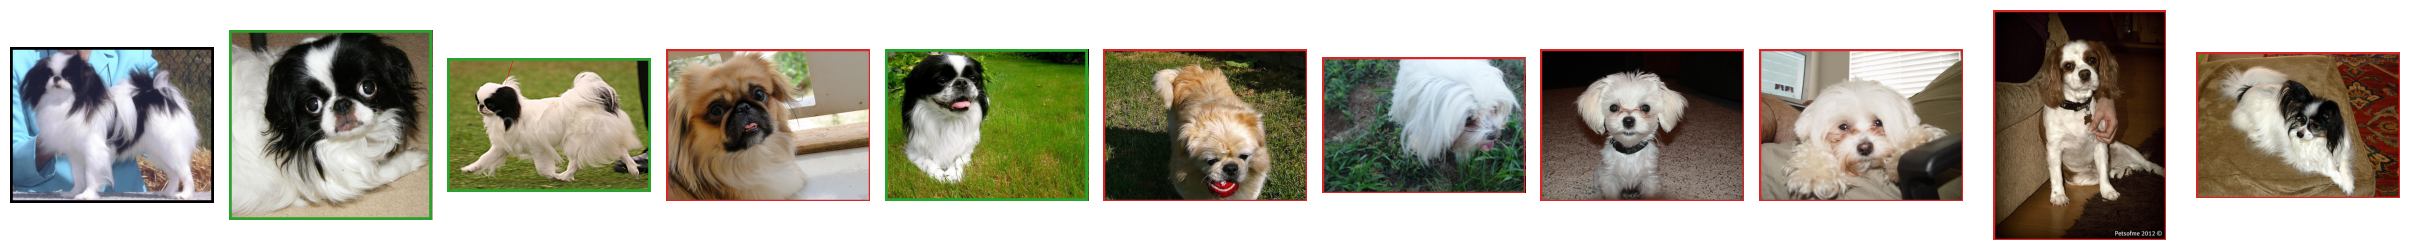

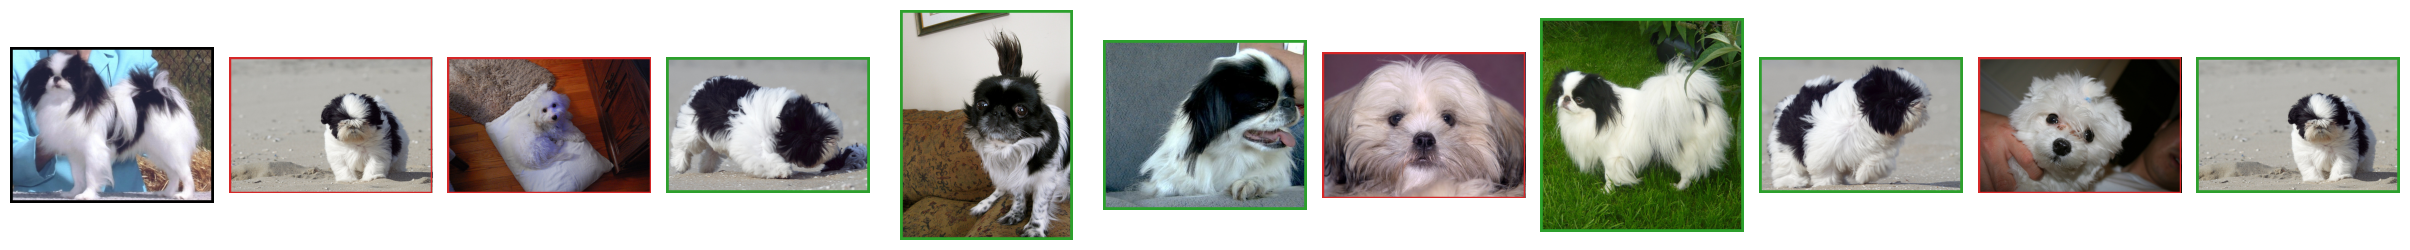

No Adaptation: 3, Adaptation: 6
64


In [9]:
idx = random.randint(0, 16 * 32) # 146; 64 81 366 416 244 !448 179 48 192
idx = 64
in_batch = False
plot = True

# if plot:
    # show_imgnet(adapt['indices'][idx].item(), title=f"L:{adapt['labels'][idx]}")
same_no_adapt = get_knn(no_adapt, idx, in_batch=in_batch, batch_size=16, k=10, plot=plot);
same_adapt = get_knn(adapt, idx, in_batch=in_batch, batch_size=16, k=10, plot=plot);

print(f"No Adaptation: {same_no_adapt}, Adaptation: {same_adapt}")
print(idx)

In [10]:
from matplotlib.patches import Rectangle

def plot_knn_same_figure(msgs_list, titles, query_idx,
                         k=10, batch_size=16, in_batch=False,
                         dataset="imagenet"):

    rows = len(msgs_list)
    cols = k + 1  # query + neighbors

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(2.2 * cols, 2.6 * rows)
    )

    if rows == 1:
        axes = axes[None, :]

    for r, (msgs, title) in enumerate(zip(msgs_list, titles)):

        # --- SAME LOGIC AS get_knn ---
        if in_batch:
            start = batch_size * (query_idx // batch_size)
            end = start + batch_size
            qidx = query_idx % batch_size
        else:
            start = 0
            end = len(msgs["words"])
            qidx = query_idx

        words = msgs["words"][start:end]
        query = words[qidx]

        msg_dist = (words != query).sum(dim=-1)
        msg_dist[qidx] = 100

        knn = torch.topk(msg_dist, k, largest=False)
        nearest_idxs = knn.indices.tolist()

        query_label = msgs["labels"][start:end][qidx]
        all_idxs = [qidx] + nearest_idxs
        # --------------------------------

        for c, idx in enumerate(all_idxs):
            ax = axes[r, c]
            ax.axis("off")

            if dataset == "imagenet":
                img = get_imgnet_img(msgs["indices"][start:end][idx].item())
            else:
                img = msgs["imgs"][start:end][idx]

            ax.imshow(img)

            label = msgs["labels"][start:end][idx]
            is_same = (label == query_label)

            # border style
            if idx == query_idx:
                edge_color, lw = "black", 4.0
            elif is_same:
                edge_color, lw ="#2ca02c", 4.0   # same class  "#2ca02c"
            else:
                edge_color, lw = "#d62728", 2.5   # different class
        
            # draw border in AXES coordinates (always visible)
            rect = Rectangle(
                (0, 0), 1, 1,
                transform=ax.transAxes,
                linewidth=lw,
                edgecolor=edge_color,
                facecolor="none"
            )
            ax.add_patch(rect)

            # row label
            if c == 0:
                ax.text(
                    -0.18, 0.5, title,
                    transform=ax.transAxes,
                    ha="right", va="center",
                    fontsize=11, fontweight="bold",
                    rotation=90
                )

    plt.tight_layout()
    plt.show()


In [11]:
same_no_adapt = get_knn(
    no_adapt, idx,
    in_batch=in_batch, batch_size=16, k=10, plot=False
)

same_adapt = get_knn(
    adapt, idx,
    in_batch=in_batch, batch_size=16, k=10, plot=False
)


In [12]:
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch

TARGET_SIZE = (224, 224)  # (width, height)

def resize_image(img):
    if isinstance(img, np.ndarray):
        img = Image.fromarray(img)
    # img = img.resize(TARGET_SIZE, Image.BILINEAR)
    img = img.resize(TARGET_SIZE, Image.LANCZOS)

    return np.asarray(img)


def plot_knn_multiple_examples(
    msgs_list, titles,
    query_indices,
    k=10, batch_size=16, in_batch=False,
    dataset="imagenet"
):

    num_examples = len(query_indices)
    rows_per_example = len(msgs_list)  # e.g. 2

    # +1 query, +1 spacer, +k neighbors
    cols = k + 2

    # fig = plt.figure(figsize=(2.2 * cols, 2.6 * rows_per_example * num_examples))
    fig = plt.figure(figsize=(2.4 * cols, 2.8 * rows_per_example * num_examples))


    # Make spacer column wider
    width_ratios = [1.2, 0.55] + [1.0] * k

    gs = gridspec.GridSpec(
        rows_per_example * num_examples,
        cols,
        width_ratios=width_ratios,
        wspace=0.05,
        hspace=0.15
    )

    for e, qidx_global in enumerate(query_indices):

        # ---------- compute query ONCE ----------
        if in_batch:
            start = batch_size * (qidx_global // batch_size)
            end = start + batch_size
            qidx = qidx_global % batch_size
        else:
            start = 0
            end = len(msgs_list[0]["words"])
            qidx = qidx_global

        query_label = msgs_list[0]["labels"][start:end][qidx]

        # ---------- QUERY AXIS (spans rows) ----------
        q_ax = fig.add_subplot(
            gs[e * rows_per_example:(e + 1) * rows_per_example, 0]
        )
        q_ax.axis("off")

        if dataset == "imagenet":
            q_img = get_imgnet_img(
                msgs_list[0]["indices"][start:end][qidx].item()
            )
        else:
            q_img = msgs_list[0]["imgs"][start:end][qidx]

        q_ax.imshow(resize_image(q_img))
        q_ax.add_patch(Rectangle(
            (0, 0), 1, 1,
            transform=q_ax.transAxes,
            linewidth=4.5,
            edgecolor="black",
            facecolor="none"
        ))

        # ---------- EACH CONDITION ----------
        for r, (msgs, title) in enumerate(zip(msgs_list, titles)):

            row = e * rows_per_example + r

            words = msgs["words"][start:end]
            query = words[qidx]

            msg_dist = (words != query).sum(dim=-1)
            msg_dist[qidx] = 100

            knn = torch.topk(msg_dist, k, largest=False)
            nearest_idxs = knn.indices.tolist()

            for c, idx in enumerate(nearest_idxs):
                # +2 to skip query and spacer
                ax = fig.add_subplot(gs[row, c + 2])
                ax.axis("off")

                if dataset == "imagenet":
                    img = get_imgnet_img(
                        msgs["indices"][start:end][idx].item()
                    )
                else:
                    img = msgs["imgs"][start:end][idx]

                ax.imshow(resize_image(img))

                label = msgs["labels"][start:end][idx]
                is_same = (label == query_label)
                # plt.title(msgs["indices"][start:end][idx].item())

                if is_same:
                    edge_color, lw = "#2ca02c", 6.5
                else:
                    edge_color, lw = "#d62728", 4.5

                ax.add_patch(Rectangle(
                    (0, 0), 1, 1,
                    transform=ax.transAxes,
                    linewidth=lw,
                    edgecolor=edge_color,
                    facecolor="none"
                ))

                # ---------- TITLE GOES INTO SPACER ----------
                if c == 0:
                    ax.text(
                        -0.1, 0.5, title,
                        transform=ax.transAxes,
                        ha="right", va="center",
                        fontsize=13,
                        fontweight="bold",
                        rotation=90
                    )

    plt.tight_layout()

/tmp/ipykernel_821853/1286264051.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


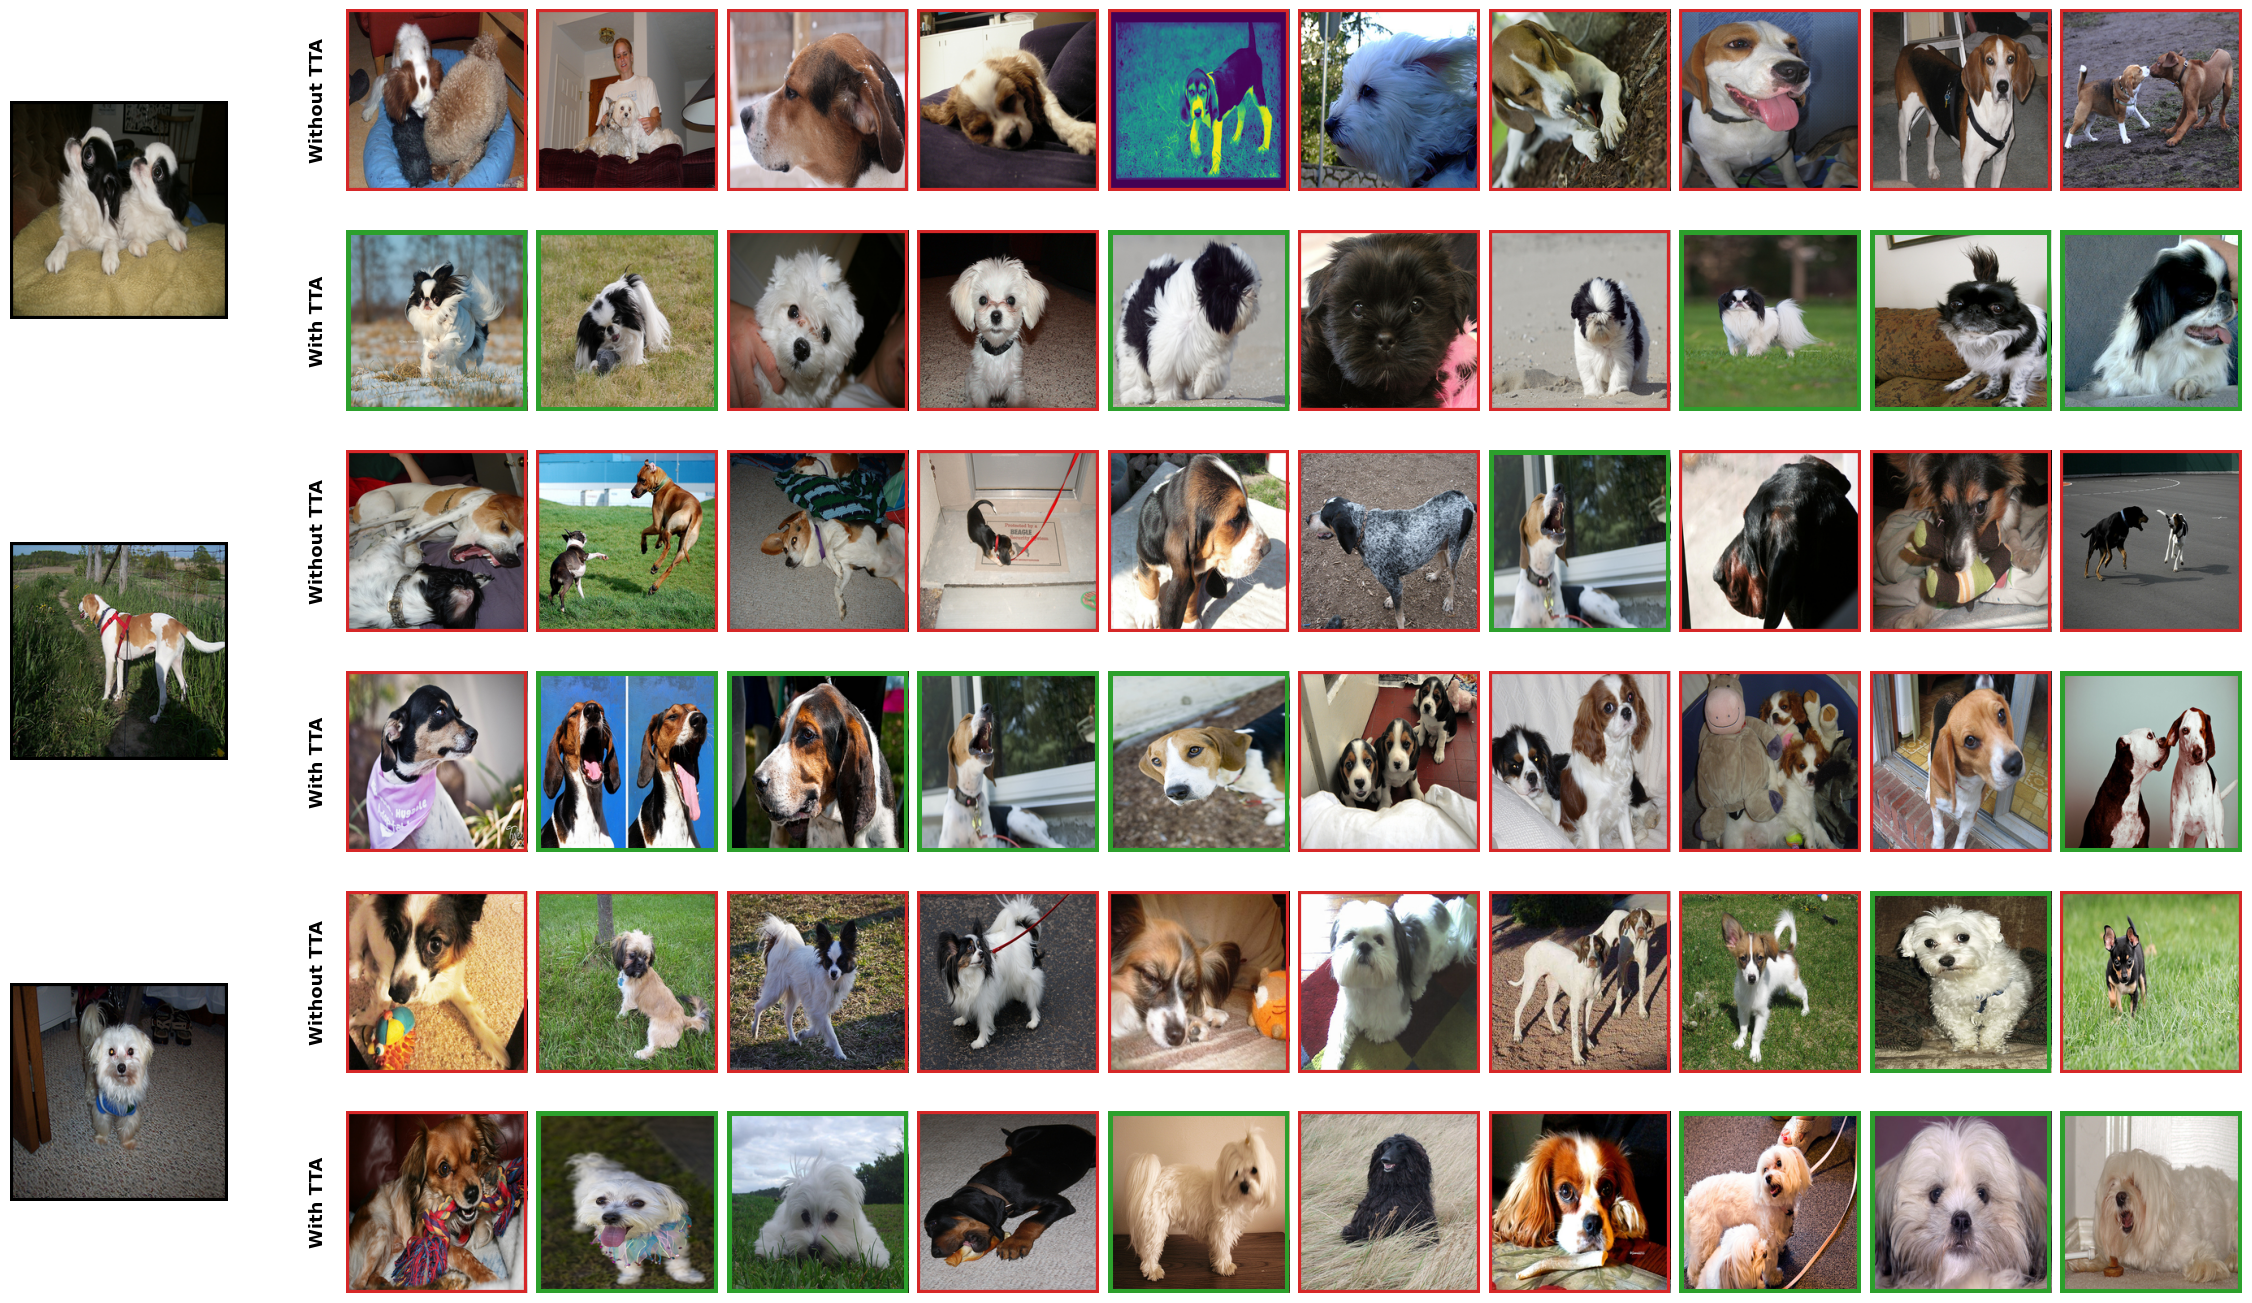

In [14]:
plot_knn_multiple_examples(
    msgs_list=[no_adapt, adapt],
titles = ["Without TTA", "With TTA"],
    query_indices=[48, 366, 81],
    k=10,
    batch_size=16,
    in_batch=in_batch,
    dataset="imagenet"
)


plt.savefig(
    "../assets/knn_examples.pdf",   # PDF preferred for ACL
    format="pdf",
    dpi=150,
    bbox_inches="tight"
)
plt.show() # 152 / 166 /  153


## MNIST

In [ ]:
batch_msg4_iter0 = torch.load("msgs/mnist1_batch_msglen4_iter0.pt")
batch_msg9_iter200 = torch.load("msgs/mnist1_batch_msglen9_iter200.pt")
dataset_msg9_iter10 = torch.load("msgs/mnist1_dataset_msglen9_iter10.pt")

In [ ]:
idx = random.randint(0, 2000)

show_img(batch_msg9_iter200['imgs'][idx])

in_batch = False
get_knn(batch_msg4_iter0, idx, dataset="mnist", in_batch=in_batch, batch_size=100)
get_knn(dataset_msg9_iter10, idx, dataset="mnist", in_batch=in_batch, batch_size=100);
# get_knn(batch_msg9_iter200, idx, dataset="mnist", in_batch=in_batch, batch_size=100);

## Shape

In [ ]:
batch_msg4_iter0 = torch.load("msgs/shape1_batch_msglen4_iter0.pt")
batch_msg9_iter200 = torch.load("msgs/shape1_batch_msglen9_iter200.pt")
dataset_msg7_iter5 = torch.load("msgs/shape1_dataset_msglen7_iter5.pt")

In [ ]:
idx = random.randint(0, 2000) # 45, 864

show_img(batch_msg4_iter0['imgs'][idx])

in_batch = False
get_knn(batch_msg4_iter0, idx, in_batch=in_batch, dataset='shape')
get_knn(batch_msg9_iter200, idx, in_batch=in_batch, dataset='shape');
get_knn(dataset_msg7_iter5, idx, in_batch=in_batch, dataset='shape');

---

In [ ]:
import glob
import pandas as pd

files = sorted(glob.glob("/home/shared/data/imagenet/validation-*.parquet"))
df = pd.read_parquet(files)


In [ ]:
# take the first sample from each class
df_one_per_class = (
    df.groupby("label", sort=True)
      .first()
      .reset_index()
)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

num_classes = len(df_one_per_class)
cols = 10                      # adjust for readability
rows = int(np.ceil(num_classes / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.2))
axes = axes.flatten()

for ax, (_, row) in zip(axes, df_one_per_class.iterrows()):
    img = row["image"]         # ndarray or PIL-compatible
    label = row["label"]
    # idx = row["idx"]

    img_bytes = img['bytes']
    img = Image.open(io.BytesIO(img_bytes))

    ax.imshow(img)
    ax.set_title(f"label={label}", fontsize=6)
    ax.axis("off")

# turn off any unused subplots
for ax in axes[num_classes:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
class_i_df = df[df["label"] == 213].reset_index()
idx = random.randint(0, 49)
show_imgnet(idx, df=class_i_df)

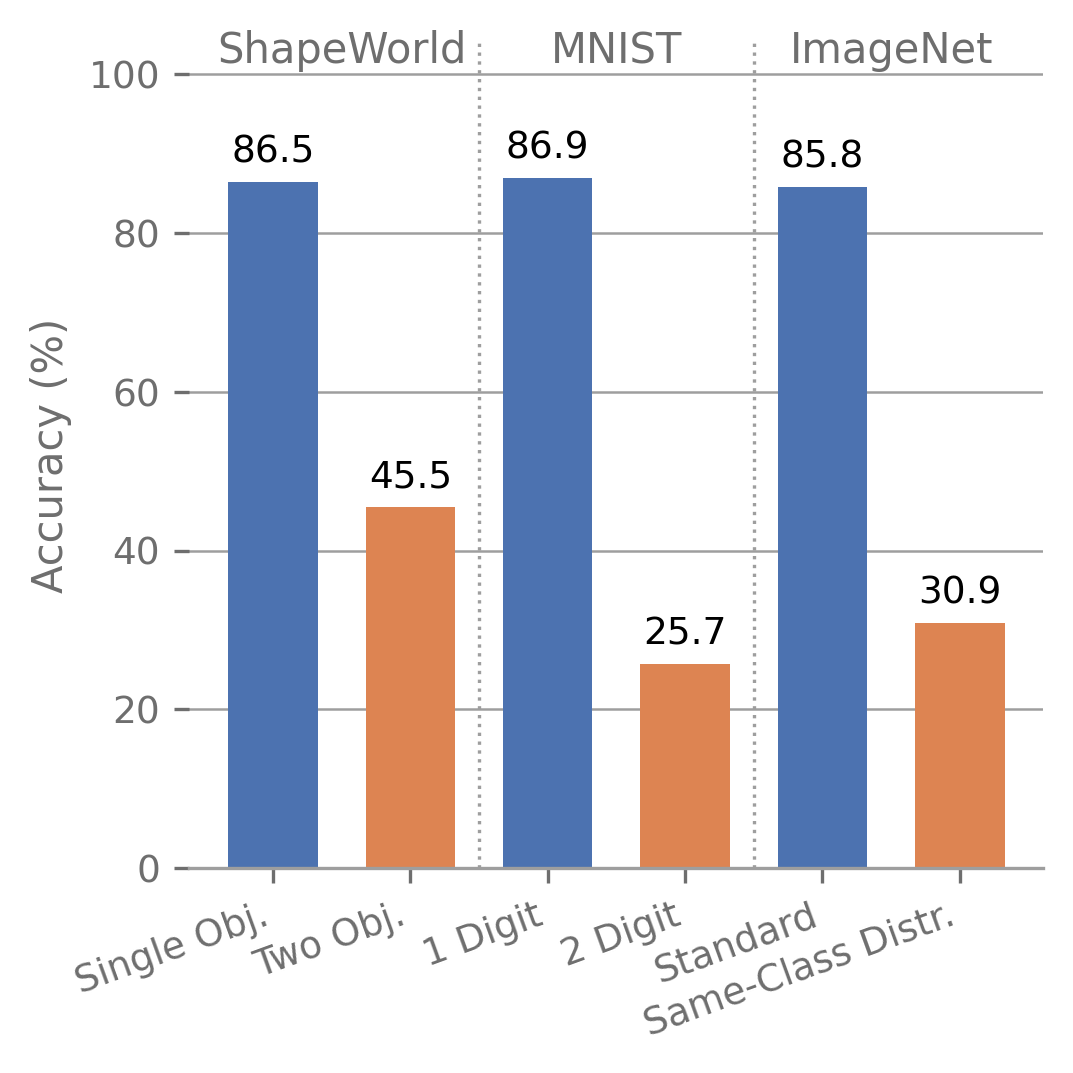

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data
means = [86.5, 45.5, 86.9, 25.7, 85.8, 30.9]

labels = [
    "Single Obj.",
    "Two Obj.",
    "1 Digit",
    "2 Digit",
    "Standard",
    "Same-Class Distr."
]

groups = ["ID", "OOD", "ID", "OOD", "ID", "OOD"]
x = np.arange(len(means))

# Colors
id_color = "#4C72B0"
ood_color = "#DD8452"
colors = [id_color if g == "ID" else ood_color for g in groups]

axis_gray = "#6E6E6E"
light_gray = "#9E9E9E"

# High-quality, square figure for ACL
fig, ax = plt.subplots(figsize=(3.6, 3.6), dpi=300)

# Bars
bars = ax.bar(x, means, color=colors, width=0.65)

# Values on top (black)
for bar, val in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 1.5,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

# Axes
ax.set_ylabel("Accuracy (%)", fontsize=10, color=axis_gray)
ax.set_ylim(0, 104)  # headroom for dataset labels

ax.set_xticks(x)
ax.set_xticklabels(
    labels,
    fontsize=9,
    rotation=20,
    ha="right",
    color=axis_gray
)

ax.tick_params(axis="y", labelsize=9, colors=axis_gray)
ax.tick_params(axis="x", colors=axis_gray)

# Solid horizontal grid
ax.yaxis.grid(True, linestyle="-", linewidth=0.6, color=light_gray)
ax.set_axisbelow(True)

# Dataset separators
ax.axvline(1.5, linestyle=":", linewidth=0.8, color=light_gray)
ax.axvline(3.5, linestyle=":", linewidth=0.8, color=light_gray)

# Dataset titles ABOVE 100%
ax.text(0.5, 101.5, "ShapeWorld", ha="center", fontsize=10, color=axis_gray)
ax.text(2.5, 101.5, "MNIST", ha="center", fontsize=10, color=axis_gray)
ax.text(4.5, 101.5, "ImageNet", ha="center", fontsize=10, color=axis_gray)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(light_gray)
ax.spines["bottom"].set_linewidth(0.8)

# Tight layout with extra top padding
plt.tight_layout(pad=0.8)
plt.savefig("../assets/reinforce_results.pdf", bbox_inches="tight")

plt.show()


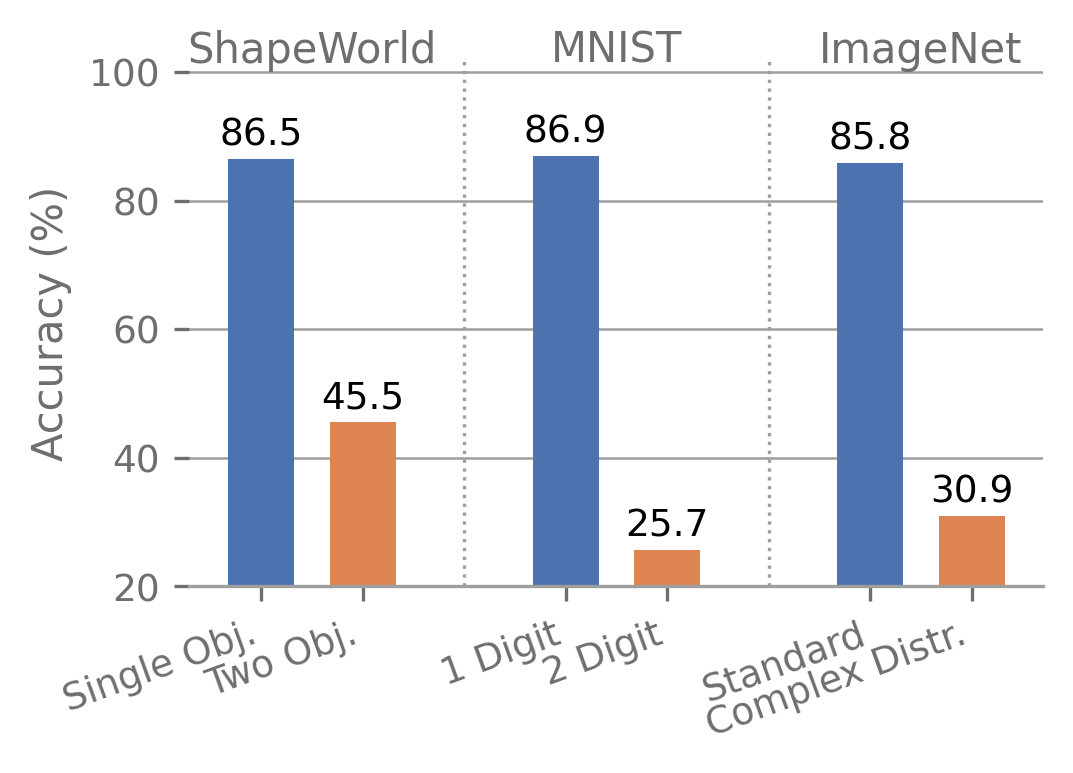

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Data
means = [86.5, 45.5, 86.9, 25.7, 85.8, 30.9]

labels = [
    "Single Obj.",
    "Two Obj.",
    "1 Digit",
    "2 Digit",
    "Standard",
    "Complex Distr."
]

groups = ["ID", "OOD", "ID", "OOD", "ID", "OOD"]

# ---- NEW: custom x positions with gaps between pairs ----
x = np.array([0, 1,   3, 4,   6, 7])  # gaps after every 2 bars

# Colors
id_color = "#4C72B0"
ood_color = "#DD8452"
colors = [id_color if g == "ID" else ood_color for g in groups]

axis_gray = "#6E6E6E"
light_gray = "#9E9E9E"

# High-quality, square figure for ACL
fig, ax = plt.subplots(figsize=(3.6, 2.6), dpi=300)

# Bars
bars = ax.bar(x, means, color=colors, width=0.65)

# Values on top (black)
for bar, val in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 1.0,
        f"{val:.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
        color="black"
    )

# ---- Y range LIMITED ----
ax.set_ylabel("Accuracy (%)", fontsize=10, color=axis_gray)
ax.set_ylim(20, 104)
ax.set_ylim(25, 102)
ax.set_yticks([20, 40, 60, 80, 100])
# X ticks
ax.set_xticks(x)
ax.set_xticklabels(
    labels,
    fontsize=9,
    rotation=20,
    ha="right",
    color=axis_gray
)

ax.tick_params(axis="y", labelsize=9, colors=axis_gray)
ax.tick_params(axis="x", colors=axis_gray)

# Solid horizontal grid
ax.yaxis.grid(True, linestyle="-", linewidth=0.6, color=light_gray)
ax.set_axisbelow(True)

# Dataset separators aligned with gaps
ax.axvline(2.0, linestyle=":", linewidth=0.8, color=light_gray)
ax.axvline(5.0, linestyle=":", linewidth=0.8, color=light_gray)

# Dataset titles ABOVE 100%
ax.text(0.5, 101.5, "ShapeWorld", ha="center", fontsize=10, color=axis_gray)
ax.text(3.5, 101.5, "MNIST", ha="center", fontsize=10, color=axis_gray)
ax.text(6.5, 101.5, "ImageNet", ha="center", fontsize=10, color=axis_gray)

# Spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color(light_gray)
ax.spines["bottom"].set_linewidth(0.8)

# Layout and save
plt.tight_layout(pad=0.8)
plt.savefig("../assets/reinforce_results.pdf", bbox_inches="tight")
plt.show()
